## DenseNet201.ipynb




In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
cd /content/gdrive/MyDrive/CSS2 Workshop/Dataset/

/content/gdrive/.shortcut-targets-by-id/1JI_Z-KQDGM-fZQIEnX8Xy-HiEn7kQuty/CSS2 Workshop/Dataset


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load HAM10000 metadata
metadata = pd.read_csv('HAM10000_metadata.csv')

# Encode categorical labels
label_encoder = LabelEncoder()
metadata['label_code'] = label_encoder.fit_transform(metadata['dx'])

In [ ]:
classes = label_encoder.classes_

In [ ]:
metadata['image_id'] = metadata['image_id'] + '.jpg'

In [ ]:
train_df, otherSplit = train_test_split(metadata, test_size=0.3) #splits 7000/300
valid_df, test_df = train_test_split(otherSplit, test_size=0.5) #splits 150/150

In [ ]:
print(train_df.shape)
print(valid_df.shape)
print(test_df.shape)

(7010, 9)
(1502, 9)
(1503, 9)


In [ ]:
# Image data generators for training and validation
train_datagen = ImageDataGenerator(
      rescale=1.0/255.0,
      rotation_range=40,
      width_shift_range=0.2,
      height_shift_range=0.2,
      shear_range=0.2,
      zoom_range=0.2,
      horizontal_flip=True,
      fill_mode='nearest')

valid_datagen = ImageDataGenerator(rescale=1.0/255.0)

# Define image size and batch size
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    directory='images',
    x_col='image_id',
    y_col='dx',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

valid_generator = valid_datagen.flow_from_dataframe(
    valid_df,
    directory='images',
    x_col='image_id',
    y_col='dx',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = valid_datagen.flow_from_dataframe(
    test_df,
    directory='images',
    x_col='image_id',
    y_col='dx',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 7010 validated image filenames belonging to 7 classes.
Found 1502 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.


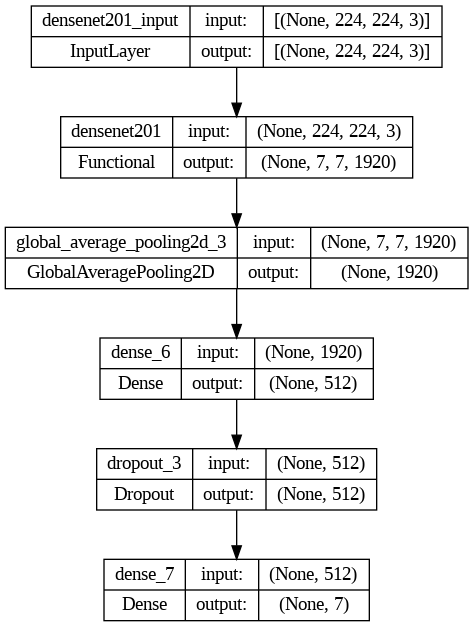

In [ ]:
from tensorflow.keras.applications import VGG16, DenseNet201, InceptionResNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D

# Load pre-trained VGG16 model without the top (fully connected) layers
base_model = DenseNet201(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

# Create new model on top
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(7, activation='softmax')  # 7 classes in HAM10000 dataset
])

# Compile the model
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.999, amsgrad=True)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

#Visualize Network Model
modelViz_file= 'model_1.png' # Model filename

# Plot model
tf.keras.utils.plot_model(model, to_file=modelViz_file, show_shapes=True)

In [ ]:
# Train the model
with tf.device('/device:GPU:0'):
  history = model.fit(
      train_generator,
      epochs=5,
      validation_data=valid_generator,
  )

Epoch 1/5
220/220 [==============================] - 144s 655ms/step - loss: 0.8529 - accuracy: 0.6974 - val_loss: 0.8039 - val_accuracy: 0.7044
Epoch 2/5
220/220 [==============================] - 140s 638ms/step - loss: 0.7877 - accuracy: 0.7211 - val_loss: 0.7632 - val_accuracy: 0.7244
Epoch 3/5
220/220 [==============================] - 141s 640ms/step - loss: 0.7595 - accuracy: 0.7268 - val_loss: 0.7583 - val_accuracy: 0.7304
Epoch 4/5
220/220 [==============================] - 141s 639ms/step - loss: 0.7429 - accuracy: 0.7297 - val_loss: 0.7301 - val_accuracy: 0.7437
Epoch 5/5
220/220 [==============================] - 141s 640ms/step - loss: 0.7196 - accuracy: 0.7382 - val_loss: 0.7173 - val_accuracy: 0.7510


In [ ]:
for layer in base_model.layers:
    layer.trainable = True

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

learning_rate_reduction = ReduceLROnPlateau(monitor='val_acc', patience=3, verbose=1, factor=0.5,
                                            min_lr=0.000001, cooldown=3)

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.999, amsgrad=False)
model.compile(loss='categorical_crossentropy',
              optimizer=optimizer,
              metrics=['acc'])

In [ ]:
with tf.device('/device:GPU:0'):
  history = model.fit(
      train_generator,
      epochs=20,
      validation_data=valid_generator,
      callbacks=[learning_rate_reduction]
  )

Epoch 1/20
220/220 [==============================] - 179s 663ms/step - loss: 0.6971 - acc: 0.7501 - val_loss: 0.6260 - val_acc: 0.7850 - lr: 1.0000e-04
Epoch 2/20
220/220 [==============================] - 141s 640ms/step - loss: 0.5581 - acc: 0.7951 - val_loss: 0.5819 - val_acc: 0.7936 - lr: 1.0000e-04
Epoch 3/20
220/220 [==============================] - 141s 642ms/step - loss: 0.4884 - acc: 0.8178 - val_loss: 0.5154 - val_acc: 0.8103 - lr: 1.0000e-04
Epoch 4/20
220/220 [==============================] - 141s 642ms/step - loss: 0.4439 - acc: 0.8371 - val_loss: 0.5300 - val_acc: 0.8169 - lr: 1.0000e-04
Epoch 5/20
220/220 [==============================] - 141s 642ms/step - loss: 0.3958 - acc: 0.8531 - val_loss: 0.5256 - val_acc: 0.8316 - lr: 1.0000e-04
Epoch 6/20
220/220 [==============================] - 141s 640ms/step - loss: 0.3482 - acc: 0.8696 - val_loss: 0.5834 - val_acc: 0.8069 - lr: 1.0000e-04
Epoch 7/20
220/220 [==============================] - 142s 644ms/step - loss: 0.32

In [ ]:
with tf.device('/device:GPU:0'):
  model.evaluate(test_generator)

47/47 [==============================] - 22s 468ms/step - loss: 0.6234 - acc: 0.8377


In [ ]:
model.save('denseNet3.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
